# NL-3 aside — a *genuine* multi-frequency Continuum Memory System

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bdsaglam/bdsaglam.github.io/blob/main/courses/continual-learning/tracks/nested-learning/nl3-aside-continuum-memory.ipynb)

*A companion to [NL-3](nl3-hope.ipynb), built to answer one question: the [HOPE-training aside](nl3-aside-training-hope.ipynb) used a block it called "CMS" — but that was a single `Linear→GELU→Linear` MLP updated once per training step, i.e. the **degenerate $k$=1, single-frequency case** (which is just a Transformer MLP, [NL-2](nl2-levels-continuum-memory.ipynb) §4). It had no continuum of frequencies. So what does the real thing look like? Optional.*

Runs on CPU in seconds; pure PyTorch, no GPU.

This notebook builds it: **a chain of memories that update *in-context* at genuinely different frequencies** ([NL](https://arxiv.org/abs/2512.24695) Eq. 70–71, and the head-wise variant of Eq. 74), instrumented so you can *see* the levels.

The point to demonstrate concretely:

- the levels update at **different cadences** — a fast level rewrites itself every step, a slow level only at chunk boundaries;
- the fast level **churns** (large cumulative parameter movement) while the slow level stays nearly **persistent**;
- the multi-frequency system **works** on a non-stationary task, and the continuum modestly **beats any single frequency**.

> Grounding: [NL](https://arxiv.org/abs/2512.24695) §7.1 (CMS; Eq. 71's chunked per-level update; Eq. 74's head-wise variant). Builds on [NL-2](nl2-levels-continuum-memory.ipynb) (levels = update frequency) and [NL-3](nl3-hope.ipynb) (HOPE).

## 1. What "multi-frequency" means here

A CMS is a set of memories $\mathcal M^{(f_1)},\dots,\mathcal M^{(f_k)}$ at $k$ different frequencies. In the **head-wise variant** (Eq. 74) they run on the same input and their outputs are combined, $\mathbf y_t=\text{Agg}\big(\mathcal M^{(f_k)}(\mathbf x_t),\dots,\mathcal M^{(f_1)}(\mathbf x_t)\big)$ — the paper leaves $\text{Agg}(\cdot)$ arbitrary and suggests a learnable weighted sum; we use a plain sum. Level $\ell$'s parameters update only **every $C^{(\ell)}$ steps**, accumulating their update over the chunk and applying it at the boundary (Eq. 71). $C^{(\ell)}=1$ is the fastest level (rewrites every step); a large $C^{(\ell)}$ is a slow, persistent level.

We learn **online** on a *non-stationary* target — a linear map $W$ that **drifts a little every step** — so there is genuinely something for a fast level to track and something for a slow level to stabilize. (We use a linear memory per level for clarity; the paper uses residual-MLP blocks — deep memories, NL-1 — but the *frequency* structure is identical.)

In [ ]:
import numpy as np
import torch

torch.manual_seed(0)
d = 16


def run(periods, lr=0.5, T=600, drift=0.01, seed=1, record=False):
    gen = torch.Generator().manual_seed(seed)
    W = torch.randn(d, d, generator=gen) / np.sqrt(d)
    dW = torch.randn(d, d, generator=gen) / np.sqrt(d) * drift  # slow drift direction
    Ms = [torch.zeros(d, d) for _ in periods]
    acc = [torch.zeros(d, d) for _ in periods]
    cnt = [0] * len(periods)
    updates = [0] * len(periods)
    movement = [0.0] * len(periods)
    err_curve = []
    move_ts = [[] for _ in periods]  # per-level cumulative |Δθ| over time
    for t in range(T):
        W = W + dW  # target drifts (non-stationary)
        x = torch.randn(d, generator=gen)
        x /= x.norm()
        y = W @ x
        err = sum(M @ x for M in Ms) - y  # head-wise output (Eq. 74)
        err_curve.append(err.norm().item())
        for l, Cl in enumerate(periods):
            acc[l] += torch.outer(err, x)
            cnt[l] += 1  # accumulate this level's gradient
            if cnt[l] >= Cl:  # chunk boundary -> update level l (Eq. 71)
                upd = lr * acc[l] / cnt[l]
                Ms[l] = Ms[l] - upd
                movement[l] += upd.norm().item()
                acc[l] = torch.zeros(d, d)
                cnt[l] = 0
                updates[l] += 1
        if record:
            for l in range(len(periods)):
                move_ts[l].append(movement[l])
    return np.array(err_curve), updates, movement, move_ts


periods = [1, 10, 50]
err, updates, movement, move_ts = run(periods, record=True)
print(f"CMS with update periods C = {periods}  (level 0 fastest, level {len(periods) - 1} slowest)")
for l, Cl in enumerate(periods):
    print(f"  level {l}  (C={Cl:>2}):  {updates[l]:>3} updates over 600 steps,   cumulative |Δθ| = {movement[l]:.2f}")
print(f"\nmean tracking error over 2nd half: {err[300:].mean():.3f}")

CMS with update periods C = [1, 10, 50]  (level 0 fastest, level 2 slowest)
  level 0  (C= 1):  600 updates over 600 steps,   cumulative |Δθ| = 103.59
  level 1  (C=10):   60 updates over 600 steps,   cumulative |Δθ| = 3.83
  level 2  (C=50):   12 updates over 600 steps,   cumulative |Δθ| = 0.50

mean tracking error over 2nd half: 0.320


**The levels are real.** Read the counts: level 0 updates **every step** (600 updates) and its parameters move a lot (it is constantly rewriting itself to track the drift); level 2 updates only **12 times** and barely moves — a slow, persistent store. Three genuinely different frequencies, exactly as [NL-2](nl2-levels-continuum-memory.ipynb) defines a level. Now plot the cumulative movement over time and the different cadences become a picture.

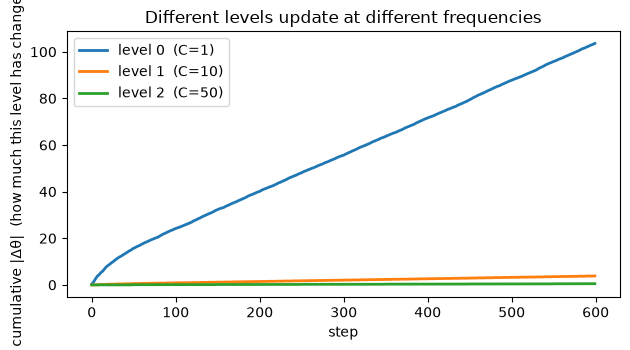

fast level: smooth steady climb (updates every step).
slow levels: flat plateaus broken by occasional steps (updates only at chunk boundaries).


In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6.4, 3.6))
for l, Cl in enumerate(periods):
    plt.plot(move_ts[l], label=f"level {l}  (C={Cl})", lw=2)
plt.xlabel("step"); plt.ylabel("cumulative |Δθ|  (how much this level has changed)")
plt.title("Different levels update at different frequencies")
plt.legend(); plt.tight_layout(); plt.show()
print("fast level: smooth steady climb (updates every step).")
print("slow levels: flat plateaus broken by occasional steps (updates only at chunk boundaries).")

## 2. Does the continuum help? — vs single frequencies

Compare the 3-level CMS against using only one frequency. On this fast-drifting target a *single slow* level can't keep up; a single fast level does most of the work; and the **continuum edges out the best single frequency** by adding stable levels under the fast one.

In [3]:
print(f"{'config':>18}  {'mean tracking err (2nd half)':>28}  {'updates/level':>16}")
for name, P in [("fast only [1]", [1]), ("slow only [50]", [50]),
                ("CMS [1,50]", [1, 50]), ("CMS [1,10,50]", [1, 10, 50])]:
    e, u, m, _ = run(P)
    print(f"{name:>18}  {e[300:].mean():>28.3f}  {str(u):>16}")
print("\nslow-only can't track the drift; fast-only does most of the work;")
print("the continuum [1,10,50] is best — fast level tracks the drift, slower levels add a stable backbone.")

            config  mean tracking err (2nd half)     updates/level
     fast only [1]                         0.354             [600]
    slow only [50]                         4.049              [12]
        CMS [1,50]                         0.347         [600, 12]
     CMS [1,10,50]                         0.320     [600, 60, 12]

slow-only can't track the drift; fast-only does most of the work;
the continuum [1,10,50] is best — fast level tracks the drift, slower levels add a stable backbone.


## What this shows — and the honest scope

- **This is a real continuum**, not the $k$=1 MLP: three memories updating in-context at three different frequencies (Eq. 71), instrumented so you can see the fast level churn and the slow levels persist. That is precisely the "levels (frequencies)" that the [HOPE-training aside](nl3-aside-training-hope.ipynb)'s block lacked.
- **It works and the continuum helps** — on a non-stationary target the multi-frequency system tracks better than any single frequency, modestly.

**Honest scope.** The gain here is *modest*, and on a fast-drifting target the fast level does most of the work — adding levels is a small, consistent improvement, not a dramatic one. The *large* payoff CMS is built for — resisting **catastrophic forgetting** across many tasks over a long lifetime (§7.1) — is not something a small linear toy shows cleanly; it needs the full nonlinear, nested machinery, meta-learned initial states, and scale (the same caveat as [NL-2](nl2-levels-continuum-memory.ipynb) §4 and [NL-3](nl3-hope.ipynb) §6). What this notebook *does* settle is the mechanical question: a genuine CMS has multiple levels at multiple frequencies, and here they are, measured.

> **Back-reference.** In the [HOPE-training aside](nl3-aside-training-hope.ipynb) the `cms` block is the degenerate **$k$=1** case (one MLP, one frequency = a Transformer MLP). This notebook is the $k\ge 2$ continuum it was standing in for.